In [55]:
#code to create unique occupied states plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec
from sklearn.metrics import roc_curve, auc

In [56]:
# [trained_on]_[data_from]
top_qcd = pd.read_csv("../output/plot_data/probs_50_epochs/top_qcd.csv")
top_top = pd.read_csv("../output/plot_data/probs_50_epochs/top_top.csv")
qcd_qcd = pd.read_csv("../output/plot_data/probs_50_epochs/qcd_qcd.csv")
qcd_top = pd.read_csv("../output/plot_data/probs_50_epochs/qcd_top.csv")

In [57]:
s_top_50 = top_top - qcd_top
s_qcd_50 = top_qcd - qcd_qcd

top_qcd = pd.read_csv("../output/plot_data/top_qcd.csv")
top_top = pd.read_csv("../output/plot_data/top_top.csv")
qcd_qcd = pd.read_csv("../output/plot_data/qcd_qcd.csv")
qcd_top = pd.read_csv("../output/plot_data/qcd_top.csv")

s_top = top_top - qcd_top
s_qcd = top_qcd - qcd_qcd

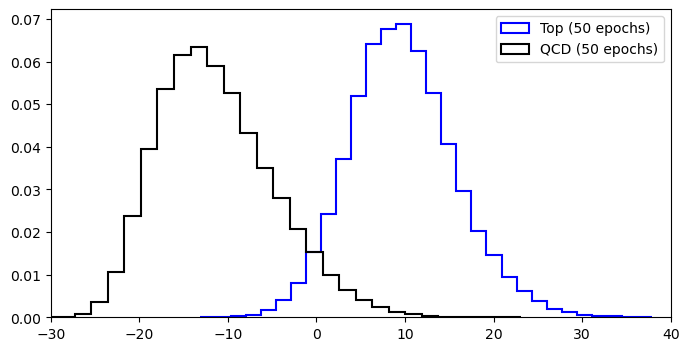

In [58]:
fig, ax = plt.subplots(figsize=(8, 4))

bins = 30

# normalized histogram (area = 1), step style
ax.hist(
    s_top_50["probs"],
    bins=bins,                 # adjust for smoothness
    density=True,            # normalization
    histtype="step",
    linewidth=1.5,
    linestyle="-",
    color="blue",
    label="Top (50 epochs)"
)

# normalized histogram (area = 1), step style
ax.hist(
    s_qcd_50["probs"],
    bins=bins,                 # adjust for smoothness
    density=True,            # normalization
    histtype="step",
    linewidth=1.5,
    linestyle="-",
    color="black",
    label="QCD (50 epochs)"
)

ax.set_xlim(-30, 40)

ax.legend()

plt.show()

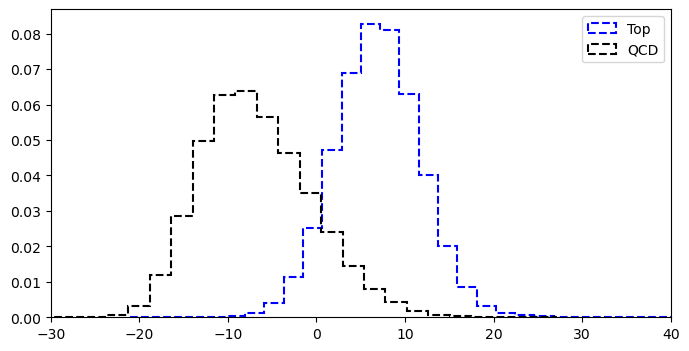

In [59]:
fig, ax = plt.subplots(figsize=(8, 4))

bins = 30

# normalized histogram (area = 1), step style
ax.hist(
    s_top["probs"],
    bins=bins,                 # adjust for smoothness
    density=True,            # normalization
    histtype="step",
    linewidth=1.5,
    linestyle="--",
    color="blue",
    label="Top"
)

# normalized histogram (area = 1), step style
ax.hist(
    s_qcd["probs"],
    bins=bins*2,                 # adjust for smoothness
    density=True,            # normalization
    histtype="step",
    linewidth=1.5,
    linestyle="--",
    color="black",
    label="QCD"
)

ax.set_xlim(-30, 40)

ax.legend()

plt.show()

In [60]:
#plot roc curve
scores_qcd_50 = s_qcd_50["probs"].to_numpy()
scores_top_50 = s_top_50["probs"].to_numpy()

scores_50 = np.concatenate([scores_top_50, scores_qcd_50])
labels_50 = np.concatenate([
    np.ones(len(scores_top_50)),
    np.zeros(len(scores_qcd_50))
])

fpr_50, tpr_50, thresholds_50 = roc_curve(labels_50, scores_50)

roc_auc_50 = auc(fpr_50, tpr_50)

scores_qcd = s_qcd["probs"].to_numpy()
scores_top = s_top["probs"].to_numpy()

scores = np.concatenate([scores_top, scores_qcd])
labels = np.concatenate([
    np.ones(len(scores_top)),
    np.zeros(len(scores_qcd))
])

fpr, tpr, thresholds = roc_curve(labels, scores)

roc_auc = auc(fpr, tpr)

/tmp/ipykernel_484222/1309532284.py:3: RuntimeWarning: divide by zero encountered in divide
  ax.plot(tpr_50, 1/fpr_50,
/tmp/ipykernel_484222/1309532284.py:7: RuntimeWarning: divide by zero encountered in divide
  ax.plot(tpr, 1/fpr,


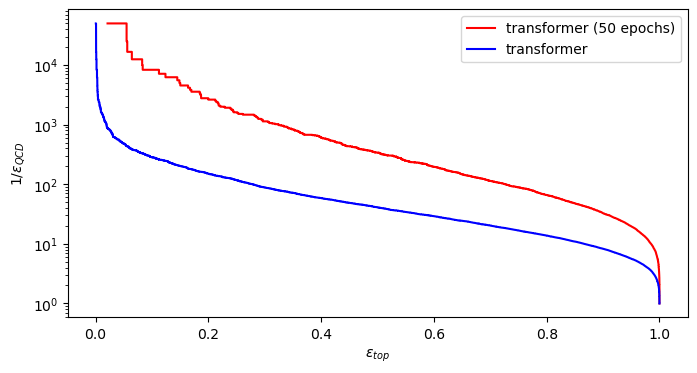

In [61]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(tpr_50, 1/fpr_50, 
        color = "red",
        label = "transformer (50 epochs)")

ax.plot(tpr, 1/fpr, 
        color = "blue",
        label = "transformer")

ax.set_yscale("log")

ax.set_xlabel(r"$\epsilon_{top}$")
ax.set_ylabel(r"$1/\epsilon_{QCD}$")

ax.legend()

plt.show()